## Import Packages/Library yang digunakan

Di bagian ini, import berbagai library yang akan digunakan dalam proyek ini.

- pandas dan numpy digunakan untuk manipulasi data.
- matplotlib dan seaborn digunakan untuk visualisasi data.
- files digunakan untuk mengunggah file di Google Colab.



In [ ]:
import pandas as pd
from google.colab import files
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

### Menunggah kaggle.json
Fungsi `files.upload()` dari Google Colab untuk mengunggah file dataset dari komputer lokal ke lingkungan notebook. Fungsi ini memungkinkan digunakan untuk mengunggah kaggle.json yang ingin digunakan dalam ini.

In [ ]:
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kornels","key":"b175815434db27754ec36fcad5ce0a80"}'}

Diperlukan beberapa langkah untuk mengonfigurasi akses ke API Kaggle dan mengunduh dataset yang dibutuhkan untuk proyek ini:

1. **Membuat Direktori untuk API Kaggle:**
   - Perintah `!mkdir ~/.kaggle` digunakan untuk membuat direktori `.kaggle` di lingkungan home pengguna. Direktori ini digunakan untuk menyimpan file kredensial API Kaggle.

2. **Memindahkan File `kaggle.json`:**
   - File `kaggle.json` yang berisi kredensial API dipindahkan ke direktori `.kaggle` menggunakan perintah `!mv kaggle.json ~/.kaggle/`. File ini diperlukan untuk mengautentikasi permintaan ke API Kaggle.

3. **Mengatur Izin Akses File:**
   - Perintah `!chmod 600 ~/.kaggle/kaggle.json` digunakan untuk mengubah izin file `kaggle.json` agar hanya pengguna yang dapat mengaksesnya. Ini meningkatkan keamanan kredensial API.

4. **Mengunduh Dataset dari Kaggle:**
   - Perintah `!kaggle datasets download arashnic/book-recommendation-dataset` digunakan untuk mengunduh dataset "Student Performance for Multiple Linear Regression" dari Kaggle. Dataset ini digunakan untuk tujuan analisis dan pembangunan model regresi linier.

Setelah menjalankan perintah-perintah ini, dataset akan diunduh dan tersedia dalam direktori kerja notebook colab untuk diproses lebih lanjut.

In [ ]:
! mkdir ~/.kaggle
! mv kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download arashnic/book-recommendation-dataset

mkdir: cannot create directory ‘/root/.kaggle’: File exists
Dataset URL: https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset
License(s): CC0-1.0


Perintah `!unzip` untuk mengekstrak file zip yang baru saja diunduh, yaitu file `book-recommendation-dataset.zip`.

`!unzip /content/book-recommendation-dataset.zip`: Perintah ini akan mengekstrak isi dari file ZIP.

Setelah mengekstrak file, file dataset yang ada di dalamnya, yang berupa file CSV akan digunakan dalam analisis lebih lanjut.

In [ ]:
!unzip /content/book-recommendation-dataset.zip

Archive:  /content/book-recommendation-dataset.zip
replace Books.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


Perintah ini menghapus file `book-recommendation-dataset.zip` yang ada di direktori `/content/` untuk menghemat ruang penyimpanan setelah file ZIP tidak lagi dibutuhkan.

Setelah perintah ini dijalankan, file ZIP yang telah diekstrak akan dihapus dari direktori kerja, sehingga hanya file dataset yang diperlukan yang tersisa untuk proses selanjutnya.

In [ ]:
!rm /content/book-recommendation-dataset.zip

Pada tahap ini, terdapat tiga file CSV yang berisi dataset yang berbeda:
- **Books.csv**: Berisi informasi mengenai buku-buku.
- **Ratings.csv**: Berisi informasi tentang rating yang diberikan oleh pengguna terhadap buku.
- **Users.csv**: Berisi informasi tentang pengguna.

Dengan informasi ini, didapatkan gambaran awal mengenai ukuran dan keberagaman data dalam dataset yang dimiliki.

In [ ]:
books = pd.read_csv("/content/Books.csv")
rating = pd.read_csv("/content/Ratings.csv")
users = pd.read_csv("/content/Users.csv")

print(f"Jumlah data user :", len(users['User-ID'].unique()))
print(f"Jumlah data rating :", len(rating))
print(f"Jumlah data books :", len(books['ISBN'].unique()))

<ipython-input-6-88b769bc6531>:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("/content/Books.csv")


Jumlah data user : 278858
Jumlah data rating : 1149780
Jumlah data books : 271360


## Exploratory Data Analysis
Pada tahap ini, dilakukan eksplorasi dataset untuk mendapatkan gambaran umum tentang struktur data dan nilai-nilai yang terkandung di dalamnya.

1. .info() : Memberikan informasi tentang tipe data dan jumlah nilai yang valid di setiap kolom.
2. .head() : Digunakan untuk melihat sekilas beberapa baris pertama dari dataset.

### Book Variabel


Pada cell ini, metode `.info()` pada dataset `books` untuk memperoleh gambaran umum tentang struktur data yang ada pada dataset buku.

In [ ]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


Pada output ini, didapatkan informasi tentang struktur dataset `books` yang berisi 271,360 baris dan 8 kolom.

Dari hasil tersebut, menunjukkan bahwa dataset memiliki 5 kolom, yaitu:
- ISBN: Berisi ID buku yang unik (tipe data: object).
- Book-Title: Menyimpan judul buku (tipe data: object).
- Book-Author: Menyimpan nama penulis buku (tipe data: object).
- Year-Of-Publication: Menyimpan tahun publikasi buku (tipe data: object).
- Publisher: Menyimpan penerbit buku (tipe data: object).
- Image-URL-S : berisi URL gambar sampul buku dalam ukuran S (tipe data: object).
- Image-URL-M : berisi URL gambar sampul buku dalam ukuran M (tipe data: object)
- Image-URL-L : berisi URL gambar sampul buku dalam ukuran L(tipe data: object).

In [ ]:
print(f"Jumlah data books :", len(books))

Jumlah data books : 271360


### Rating Variabel

Pada cell ini, metode `.info()` pada dataset `rating` untuk memperoleh gambaran umum tentang struktur data yang ada pada dataset rating.

In [ ]:
rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


Pada output ini, didapatkan informasi tentang struktur dataset `rating` yang berisi 1.149.780 baris dan 3 kolom.

Berikut adalah penjelasan lebih detail terkait hasil yang ditampilkan:
- User-ID : Berisi ID Pengguna yang unik (tipe data: int64).
- ISBN : Berisi ID buku yang unik (tipe data: object).
- Book-Rating : Berisi rating yang diberikan oleh pengguna.


In [ ]:
rating.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [ ]:
print('Jumlah userID: ', len(users['User-ID'].unique()))
print('Jumlah ISBN: ', len(books.ISBN.unique()))
print('Jumlah data rating: ', len(rating))

Jumlah userID:  278858
Jumlah ISBN:  271360
Jumlah data rating:  1149780


### User Variabel

Pada cell ini, metode .info() pada dataset `users` untuk memperoleh gambaran umum tentang struktur data yang ada pada dataset users.

In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


Pada output ini, didapatkan informasi tentang struktur dataset `users` yang berisi 278.858 baris dan 3 kolom.

Berikut adalah penjelasan lebih detail terkait hasil yang ditampilkan:
- User-ID : Berisi ID Pengguna yang unik (tipe data: int64).
- Location : Berisi lokasi geografis pengguna (tipe data: object).
- Age : Berisi usia pengguna (tipe data: float64).

In [ ]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


## Data Preprocessing

Pada tahap ini, dilakukan penggabungan (merge) antara dua DataFrame, yaitu rating dan books. Kedua dataset ini digabungkan berdasarkan kolom ISBN yang menjadi kunci identifikasi buku.

Fungsi **pd.merge()** digunakan untuk menggabungkan dua DataFrame berdasarkan kolom yang memiliki nama yang sama (dalam hal ini, ISBN).

`on='ISBN'` memastikan bahwa penggabungan dilakukan berdasarkan kolom ISBN yang ada di kedua dataset, yaitu dataset buku dan dataset rating.

Proses ini menggabungkan data yang memberikan rating untuk setiap buku dengan informasi lebih lanjut tentang buku tersebut.

In [ ]:
data = pd.merge(rating, books, on='ISBN')

In [ ]:
data

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...
...,...,...,...,...,...,...,...,...,...,...
1031131,276704,0876044011,0,Edgar Cayce on the Akashic Records: The Book o...,Kevin J. Todeschi,1998,A.R.E. Press (Association of Research &amp; Enlig,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...
1031132,276704,1563526298,9,Get Clark Smart : The Ultimate Guide for the S...,Clark Howard,2000,Longstreet Press,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...
1031133,276706,0679447156,0,Eight Weeks to Optimum Health: A Proven Progra...,Andrew Weil,1997,Alfred A. Knopf,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...
1031134,276709,0515107662,10,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,1996,Jove Books,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...


Hasilnya DataFrame baru bernama `data` akan berisi gabungan dari dataset `rating dan `books`. Dengan penggabungan data ini, didapatkan informasi yang lebih lengkap tentang buku yang diberikan rating oleh pengguna.

## Data Preparation

Kode ini memeriksa apakah ada nilai yang hilang dalam dataset menggunakan:

- `data.isnull().sum()`: Menampilkan dan memeriksa jumlah nilai hilang untuk setiap kolom.

In [ ]:
data.isnull().sum()

,0
User-ID,0
ISBN,0
Book-Rating,0
Book-Title,0
Book-Author,2
Year-Of-Publication,0
Publisher,2
Image-URL-S,0
Image-URL-M,0
Image-URL-L,4


Hasilnya ditemukan beberapa kolom dengan missing value :
- `Book-Author` : Ada 2 nilai yang kosong di kolom ini.
- `Publisher` : Ada 2 nilai yang kosong di kolom ini.
- `Image-URL-L` : Ada 4 nilai yang kosong di kolom ini.

Pada kode ini, dilakukan pembersihan data seperti berikut :    

- **Menghapus kolom yang tidak relevan**

  `.drop()` digunakan untuk menghapus kolom yang tidak relevan atau tidak diperlukan dalam analisis lebih lanjut.

- **Menghapus Nilai Kosong**

  `.dropna()` digunakan untuk menghapus baris yang memiliki nilai kosong  di mana pun dalam DataFrame.

In [ ]:
data_clean = data.drop(['Year-Of-Publication','Image-URL-S', 'Image-URL-M', 'Image-URL-L'], axis=1).dropna()

In [ ]:
data_clean.isnull().sum()

,0
User-ID,0
ISBN,0
Book-Rating,0
Book-Title,0
Book-Author,0
Publisher,0


Hasil dari kode tersebut :

**Data yang lebih fokus** : Dengan menghapus kolom yang tidak relevan, membuat dataset lebih terfokus pada atribut yang penting untuk rekomendasi.

**Kualitas Data yang Lebih Baik** : Dengan menghapus baris yang memiliki nilai kosong, memastikan bahwa model yang dibangun tidak terpengaruh oleh data yang tidak lengkap.

In [ ]:
data_clean

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Publisher
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,Ballantine Books
1,276726,0155061224,5,Rites of Passage,Judith Rae,Heinle
2,276727,0446520802,0,The Notebook,Nicholas Sparks,Warner Books
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,Cambridge University Press
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,Cambridge University Press
...,...,...,...,...,...,...
1031131,276704,0876044011,0,Edgar Cayce on the Akashic Records: The Book o...,Kevin J. Todeschi,A.R.E. Press (Association of Research &amp; Enlig
1031132,276704,1563526298,9,Get Clark Smart : The Ultimate Guide for the S...,Clark Howard,Longstreet Press
1031133,276706,0679447156,0,Eight Weeks to Optimum Health: A Proven Progra...,Andrew Weil,Alfred A. Knopf
1031134,276709,0515107662,10,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,Jove Books


In [ ]:
print(f"Number of duplicated: {data_clean.duplicated().sum()}")

Number of duplicated: 0


## Model Development : Content Based Filtering

Tahap ini merupakan pengembangan model berbasis Content-Based Filtering. Dengan menggunakan similarity antara konten buku (pengarang dan penerbit), sistem ini dapat memberikan rekomendasi buku yang relevan berdasarkan buku yang sudah dikenal atau disukai oleh pengguna.

Pada kode ini, memeriksa apakah terdapat karakter non-ASCII dalam nama pengarang buku pada kolom Book-Author. Karakter non-ASCII adalah karakter yang memiliki nilai kode ASCII lebih besar dari 127, seperti karakter dengan aksen atau simbol dari bahasa selain bahasa Inggris.

**Mengubah Kolom menjadi String** :

- `data['Book-Author'].astype(str)`: Mengubah nilai di kolom Book-Author menjadi tipe data string (jika ada nilai yang bukan string atau NaN). Hal ini dilakukan untuk menghindari error saat memproses data non-string.

**Menggunakan apply() untuk Memeriksa Karakter Non-ASCII** :

- `apply(lambda x: any(ord(c) > 127 for c in x))`:  Memeriksa apakah ada karakter dalam nama pengarang yang memiliki kode ASCII lebih besar dari 127, yang menandakan karakter non-ASCII seperti huruf aksen atau simbol dari bahasa lain.

**Menentukan Pengarang dengan Karakter Non-ASCII** :

- `mask` adalah sebuah seri boolean yang menunjukkan apakah suatu baris mengandung karakter non-ASCII atau tidak.
- `weird_authors = data[mask]['Book-Author'].unique()`: Dengan menggunakan masker mask, didapatkan daftar pengarang yang memiliki karakter non-ASCII. `unique()` digunakan untuk mendapatkan hanya nama pengarang yang unik.

Hasil dari proses ini adalah `weird_authors`, yang berisi nama-nama pengarang yang menggunakan karakter non-ASCII dalam nama mereka.

In [ ]:
mask = data['Book-Author'].astype(str).apply(lambda x: any(ord(c) > 127 for c in x))
weird_authors = data[mask]['Book-Author'].unique()

Pada cell ini terdapat fungsi `normalize_text`:

- `unicodedata.normalize('NFKD', text)` : Fungsi ini mengonversi karakter-karakter Unicode menjadi bentuk dekomposisi Normal Form KC (NFKD), yang memisahkan karakter seperti huruf aksen menjadi dua bagian (misalnya, é menjadi e dan ´).

`.encode('ascii', 'ignore')` : Setelah dekomposisi, teks diubah menjadi format ASCII. Karakter-karakter yang tidak dapat diubah ke format ASCII (seperti é yang menjadi e) akan diabaikan dan tidak disertakan dalam hasil encoding.

`.decode('ascii')` : Setelah encoding, hasilnya diubah kembali menjadi string

**Penerapan Fungsi ke Kolom Book-Author** :

`fillna('')` : Digunakan untuk mengisi nilai NaN di kolom Book-Author dengan string kosong (''), untuk mencegah error pada proses normalisasi.

`astype(str)`: Mengubah seluruh nilai dalam kolom Book-Author menjadi string, jika ada nilai yang tidak berupa string.

`apply(normalize_text)`: Fungsi normalize_text diterapkan ke setiap nilai dalam kolom Book-Author. Ini menghapus karakter non-ASCII dan mengonversinya ke bentuk ASCII standar.

Dengan melakukan normalisasi, kolom Book-Author menjadi lebih konsisten dan standar, yang membuatnya lebih mudah untuk dianalisis atau digunakan dalam model pembelajaran mesin. Ini juga membantu mencegah masalah saat melakukan pemrosesan teks atau analisis berbasis teks. Misalnya, "José" akan menjadi "Jose".

In [ ]:
import unicodedata

def normalize_text(text):
    return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii')

# Terapkan ke kolom Book-Author
data_clean['Book-Author'] = data_clean['Book-Author'].fillna('').astype(str)
data_clean['Book-Author'] = data_clean['Book-Author'].apply(normalize_text)

Pada langkah ini, **TF-IDF (Term Frequency-Inverse Document Frequency)** digunakan untuk mengekstraksi fitur teks dari kolom **`Book-Author`** dan **`Publisher`**. Tujuan utama dari langkah ini adalah untuk mengubah teks menjadi representasi numerik yang dapat digunakan dalam model pembelajaran mesin.

Kolom `content` dibuat dengan menggabungkan kolom Book-Author dan Publisher. Hal ini memungkinkan untuk mempertimbangkan informasi dari kedua kolom ini saat melakukan ekstraksi fitur. Proses fit pada TfidfVectorizer akan mengidentifikasi kata-kata unik dalam kolom content dan menghitung bobot TF-IDF untuk setiap kata.

- Hasil dari get_feature_names_out() adalah daftar semua kata dan bigram yang dikenali oleh TfidfVectorizer dari kolom content. Setiap fitur ini memiliki bobot yang mencerminkan seberapa penting kata atau bigram tersebut dalam konteks dataset.

- Dengan menggunakan TF-IDF, hal ini dapat memberikan bobot lebih pada kata-kata yang jarang muncul di seluruh dataset namun sering muncul di dokumen tertentu. Hal ini membantu model untuk fokus pada kata-kata yang lebih bermakna dan relevan.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), min_df=2)
data_clean['content'] = data_clean['Book-Author'] + ' ' + data_clean['Publisher']

tf.fit(data_clean['content'])

tf.get_feature_names_out()

array(['01', '01 thumbzzz', '078946697x', ..., 'ãµes asa', 'ãµes dom',
       'ãµes europa'], dtype=object)

**cosine similarity** digunakan untuk mengukur kesamaan antar buku berdasarkan konten mereka. Proses ini dilakukan setelah fitur teks diekstraksi menggunakan **TF-IDF**. Dengan cosine similarity, dapat ditentukan seberapa mirip dua buku berdasarkan kombinasi **Book-Author** dan **Publisher** mereka.

- `tf.fit_transform(data_clean['content'])` : Menerapkan TF-IDF pada kolom `content` yang berisi kombinasi Book-Author dan Publisher. Hasilnya adalah tfidf_matrix, yang merupakan representasi numerik dari teks yang diubah menjadi vektor. Setiap vektor ini merepresentasikan satu buku dalam ruang vektor berdasarkan fitur-fitur yang diekstraksi sebelumnya.
- `cosine_similarity(tfidf_matrix)` : Fungsi ini menghitung cosine similarity antara setiap pasangan buku berdasarkan vektor TF-IDF mereka. Nilai cosine similarity berkisar antara 0 (tidak mirip sama sekali) hingga 1 (sangat mirip). Semakin tinggi nilai similarity, semakin mirip dua buku berdasarkan konten mereka.

Cell ini menghasilkan matriks cosine similarity yang menggambarkan seberapa mirip satu buku dengan buku lainnya berdasarkan informasi teks (pengarang dan penerbit). Matriks ini sangat berguna untuk sistem rekomendasi berbasis konten, yang memanfaatkan kesamaan antar buku untuk memberikan saran yang relevan kepada pengguna.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

data_clean = data_clean.drop_duplicates(subset='Book-Title').head(20000)

tfidf_matrix = tf.fit_transform(data_clean['content'])
cosine_sim = cosine_similarity(tfidf_matrix)

In [ ]:
print(cosine_sim[0, :10])

[1.         0.         0.02843306 0.         0.         0.
 0.         0.         0.28024579 0.        ]


In [ ]:
cosine_sim_df = pd.DataFrame(cosine_sim, index=data_clean['Book-Title'], columns=data_clean['Book-Title'])
print('Shape:', cosine_sim_df.shape)

Shape: (20000, 20000)


Fungsi `book_recommendations` digunakan untuk memberikan rekomendasi buku yang mirip dengan buku yang diberikan oleh pengguna. Rekomendasi dihitung berdasarkan **cosine similarity** yang telah dihitung sebelumnya. Fungsi ini mengambil sebuah **book_title** dan mengembalikan daftar buku yang paling mirip berdasarkan pengukuran similarity.

Fungsi ini mengembalikan DataFrame yang berisi k buku yang paling mirip dengan `book_title` yang diberikan (dalam hal ini k=5). Setiap baris DataFrame berisi informasi terkait buku seperti `Book-Title`, `Book-Author`, dan `Publisher`.

In [ ]:
def book_recommendations(book_title, similarity_data=cosine_sim_df, items=data_clean[['Book-Title', 'Book-Author', 'Publisher']], k=5):
    # Mengambil data dengan menggunakan argpartition untuk melakukan partisi secara tidak langsung sepanjang sumbu yang diberikan
    # Dataframe diubah menjadi numpy
    # Range(start, stop, step)
    index = similarity_data.loc[:,book_title].to_numpy().argpartition(
        range(-1, -k, -1))

    # Mengambil data dengan similarity terbesar dari index yang ada
    closest = similarity_data.columns[index[-1:-(k+2):-1]]

    # Drop book_title agar book title yang dicari tidak muncul dalam daftar rekomendasi
    closest = closest.drop(book_title, errors='ignore')

    return pd.DataFrame(closest).merge(items).head(k)

In [ ]:
book_recommendations('The Notebook')

,Book-Title,Book-Author,Publisher
0,A Walk to Remember,Nicholas Sparks,Warner Books
1,A Bend in the Road,Nicholas Sparks,Warner Books
2,The Rescue,Nicholas Sparks,Warner Books
3,Nights in Rodanthe,Nicholas Sparks,Warner Books
4,The Guardian,Nicholas Sparks,Warner Books


In [ ]:
book_recommendations('Little Men')

,Book-Title,Book-Author,Publisher
0,Jo's Boys : From the Original Publisher,Louisa May Alcott,"Little, Brown"
1,Little Women : From the Original Publisher,Louisa May Alcott,"Little, Brown"
2,Eight Cousins (Complete and Unabridged Classics),Louisa May Alcott,Little Brown and Company
3,Little Women (Scholastic Classics),Louisa May Alcott,Scholastic
4,LITTLE WOMEN,Louisa May Alcott,Pocket


## Model Development : Collaborative Filtering

 Pada tahap ini, dilakukan **encoding** terhadap `User-ID` yang ada dalam dataset agar dapat digunakan dalam model berbasis **Collaborative Filtering**. Proses encoding ini bertujuan untuk mengubah `User-ID` yang berupa kategori menjadi format numerik agar dapat digunakan dalam model pembelajaran mesin.

 Proses encoding ini penting untuk membangun model Collaborative Filtering, karena model ini membutuhkan representasi numerik untuk setiap pengguna dan item (buku dalam hal ini). Dengan encoding ini, model dilatih untuk memprediksi rating pengguna terhadap buku yang belum mereka baca berdasarkan pola preferensi pengguna lain.

In [ ]:
# Mengubah userID menjadi list tanpa nilai yang sama
user_ids = data_clean['User-ID'].unique().tolist()
print('list userID: ', user_ids)

# Melakukan encoding userID
user_to_user_encoded = {x: i for i, x in enumerate(user_ids)}
print('encoded userID : ', user_to_user_encoded)

# Melakukan proses encoding angka ke ke userID
user_encoded_to_user = {i: x for i, x in enumerate(user_ids)}
print('encoded angka ke userID: ', user_encoded_to_user)

list userID:  [276725, 276726, 276727, 276729, 276733, 276744, 276746, 276747, 276748, 276751, 276754, 276755, 276762, 276772, 276774, 276780, 276786, 276788, 276796, 276798, 276800, 276804, 276808, 276811, 276813, 276814, 276817, 276820, 276822, 276828, 276830, 276832, 276833, 276835, 276837, 276838, 276840, 276847, 276848, 276850, 276852, 276853, 276854, 276856, 276859, 276861, 276862, 276866, 276869, 276872, 276875, 276878, 276884, 276887, 276888, 276889, 276890, 276896, 276904, 276905, 276911, 276912, 276915, 276916, 276925, 276927, 276928, 276929, 276936, 276939, 276949, 276950, 276953, 276954, 276957, 276963, 276964, 276975, 276984, 276986, 276988, 276989, 276994, 276997, 276998, 277002, 277009, 277010, 277012, 277018, 277019, 277023, 277028, 277031, 277032, 277035, 277036, 277040, 277042, 277048, 277051, 277053, 277056, 277065, 277072, 277073, 277079, 277085, 277087, 277094, 277096, 277107, 277109, 277114, 277116, 277123, 277124, 277128, 277134, 277135, 277139, 277142, 277143, 2

Pada tahap ini, dilakukan **encoding** terhadap `ISBN` (nomor id buku) yang ada dalam dataset agar dapat digunakan dalam model berbasis **Collaborative Filtering**. Proses encoding ini bertujuan untuk mengubah `ISBN` yang berupa kategori menjadi format numerik yang dapat diproses oleh model pembelajaran mesin.

In [ ]:
# Mengubah ISBN menjadi list tanpa nilai yang sama
book_ids = data_clean['ISBN'].unique().tolist()

# Melakukan proses encoding ISBN
book_to_book_encoded = {x: i for i, x in enumerate(book_ids)}

# Melakukan proses encoding angka ke ISBN
book_encoded_to_book = {i: x for i, x in enumerate(book_ids)}

Pada tahap ini, dilakukan mapping `User-ID` dan `ISBN` yang ada dalam dataset ke bentuk numerik yang sudah dilakukan encoding sebelumnya.

Proses mapping ini memungkinkan untuk mengganti ID pengguna dan ISBN buku yang semula berupa string atau kategori menjadi representasi numerik. Ini sangat penting untuk model Collaborative Filtering yang mengandalkan data numerik untuk melakukan perhitungan interaksi pengguna dengan item (buku). Selanjutnya, dapat menggunakan kolom user dan book untuk melatih model dan melakukan prediksi rating secara efektif.

In [ ]:
# Mapping userID ke dataframe user
data_clean['user'] = data_clean['User-ID'].map(user_to_user_encoded)

# Mapping ISBN ke dataframe book
data_clean['book'] = data_clean['ISBN'].map(book_to_book_encoded)

In [ ]:
# Mendapatkan jumlah user
num_users = len(user_to_user_encoded)
print(num_users)

# Mendapatkan jumlah book
num_book = len(book_encoded_to_book)
print(num_book)

# Mengubah rating menjadi nilai float
data_clean['Book-Rating'] = data_clean['Book-Rating'].values.astype(np.float32)

# Nilai minimum rating
min_rating = min(data_clean['Book-Rating'])

# Nilai maksimal rating
max_rating = max(data_clean['Book-Rating'])

print('Number of User: {}, Number of Book: {}, Min Rating: {}, Max Rating: {}'.format(
    num_users, num_book, min_rating, max_rating
))

2408
20000
Number of User: 2408, Number of Book: 20000, Min Rating: 0.0, Max Rating: 10.0


In [ ]:
df = data_clean.sample(frac=1, random_state=42)
df

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Publisher,content,user,book
12539,2041,068483376X,1.0,Succulent Wild Woman,Sark,Fireside,Sark Fireside,1155,10650
2159,277639,0440116961,0.0,A Dark &amp; Distant Shore,Reay Tannahill,Dell Publishing Company,Reay Tannahill Dell Publishing Company,266,2041
9808,651,1888451084,7.0,Kamikaze Lust,Lauren Sanders,Akashic Books,Lauren Sanders Akashic Books,817,8668
1152,277427,003008685X,8.0,Pioneers,James Fenimore Cooper,Thomson Learning,James Fenimore Cooper Thomson Learning,197,1114
17209,3740,075050059X,0.0,The Sins of Eden,Iris Gower,Ulverscroft Large Print,Iris Gower Ulverscroft Large Print,1554,13902
...,...,...,...,...,...,...,...,...,...
13374,2276,0679504885,8.0,Preparing for parenthood: Understanding your f...,Lee Salk,McKay,Lee Salk McKay,1213,11284
14371,2766,1550548913,0.0,How to Be a Canadian: Even If You Already are One,Will Ferguson,Douglas &amp; McIntyre,Will Ferguson Douglas &amp; McIntyre,1325,11964
5893,278418,0449138364,0.0,Crossfire Trail,Louis L'Amour,Ballantine Books (Mm),Louis L'Amour Ballantine Books (Mm),530,5390
882,277195,0446609323,0.0,Black Friday,James Patterson,Warner Vision,James Patterson Warner Vision,136,860


Pada tahap ini, data dipersiapkan untuk melatih model dengan cara memisahkan fitur dan target dari dataset. Selain itu, juga membagi data menjadi dua bagian: **data pelatihan (train)** dan **data validasi (validation)**. Data dibagi menjadi dua bagian: 80% untuk pelatihan (train) dan 20% untuk validasi (validation).

Fitur `x` mengandung data yang menjelaskan siapa yang memberi rating pada buku tertentu, sedangkan target `y` berisi rating yang diberikan.

In [ ]:
# Membuat variabel x untuk mencocokkan data user dan book menjadi satu value
x = df[['user', 'book']].values

# Membuat variabel y untuk membuat rating dari hasil
y = df['Book-Rating'].apply(lambda x: (x - min_rating) / (max_rating - min_rating)).values

# Membagi menjadi 80% data train dan 20% data validasi
train_indices = int(0.8 * df.shape[0])
x_train, x_val, y_train, y_val = (
    x[:train_indices],
    x[train_indices:],
    y[:train_indices],
    y[train_indices:]
)

print(x, y)

[[ 1155 10650]
 [  266  2041]
 [  817  8668]
 ...
 [  530  5390]
 [  136   860]
 [ 1906 15795]] [0.1 0.  0.7 ... 0.  0.  0. ]


Model **RecommenderNet** menggunakan pendekatan Collaborative Filtering. Ini adalah model yang digunakan untuk memprediksi rating atau preferensi pengguna terhadap buku, yang memungkinkan sistem untuk memberikan rekomendasi buku berdasarkan interaksi pengguna sebelumnya.

Model ini memberikan prediksi rating antara pengguna dan buku dalam rentang [0, 1]. Rating yang diprediksi ini dapat digunakan untuk memberikan rekomendasi buku kepada pengguna berdasarkan preferensi mereka yang dipelajari oleh model.

In [ ]:
from tensorflow.keras import layers
from tensorflow import keras
import tensorflow as tf

class RecommenderNet(tf.keras.Model):

  # Insialisasi fungsi
  def __init__(self, num_users, num_book, embedding_size, **kwargs):
    super(RecommenderNet, self).__init__(**kwargs)
    self.num_users = num_users
    self.num_book = num_book
    self.embedding_size = embedding_size
    self.user_embedding = layers.Embedding( # layer embedding user
        num_users,
        embedding_size,
        embeddings_initializer = 'he_normal',
        embeddings_regularizer = keras.regularizers.l2(1e-6)
    )
    self.user_bias = layers.Embedding(num_users, 1) # layer embedding user bias
    self.book_embedding = layers.Embedding( # layer embeddings book
        num_book,
        embedding_size,
        embeddings_initializer = 'he_normal',
        embeddings_regularizer = keras.regularizers.l2(1e-6)
    )
    self.book_bias = layers.Embedding(num_book, 1) # layer embedding book bias

  def call(self, inputs):
    user_vector = self.user_embedding(inputs[:,0]) # memanggil layer embedding 1
    user_bias = self.user_bias(inputs[:, 0]) # memanggil layer embedding 2
    book_vector = self.book_embedding(inputs[:, 1]) # memanggil layer embedding 3
    book_bias = self.book_bias(inputs[:, 1]) # memanggil layer embedding 4

    dot_user_book = tf.tensordot(user_vector, book_vector, 2)

    x = dot_user_book + user_bias + book_bias

    return tf.nn.sigmoid(x) # activation sigmoid

Model siap untuk dilatih, dengan loss function dan optimizer yang telah dipilih sesuai dengan tugas rekomendasi yang ingin diselesaikan.

Model dikompilasi menggunakan `MeanSquaredError` sebagai loss function dan `Adam` sebagai optimizer. `RootMeanSquaredError` digunakan sebagai metrik untuk mengevaluasi kinerja model.

In [ ]:
model = RecommenderNet(num_users, num_book, 50) # inisialisasi model

# model compile
model.compile(
    loss= tf.keras.losses.MeanSquaredError(),
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

Pada tahap ini, ditambahkan **EarlyStopping** sebagai callback dalam pelatihan model.

**EarlyStopping** digunakan untuk menghentikan pelatihan jika model tidak menunjukkan perbaikan yang signifikan setelah sejumlah epoch tertentu (dalam hal ini, 3 epoch berturut-turut).

Fungsi `monitor='val_root_mean_squared_error'` menunjukkan bahwa model akan memonitor metrik Root Mean Squared Error (RMSE) pada data validasi (validation set) untuk menghentikan pelatihan lebih awal jika model tidak menunjukkan peningkatan.

`patience=3` berarti pelatihan akan dihentikan jika model tidak menunjukkan perbaikan selama 3 epoch berturut-turut.

`restore_best_weights=True` memastikan bahwa bobot model yang terbaik (dengan nilai RMSE terendah di data validasi) akan dipulihkan setelah pelatihan dihentikan, sehingga model yang digunakan adalah model yang paling optimal.

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_root_mean_squared_error', # Monitor RMSE di validation set
    patience=3,
    restore_best_weights=True
)

Pada tahap ini, model dilatih menggunakan data training (x_train, y_train) dengan parameter yang sudah ditentukan sebelumnya.

Model akan dilatih selama 100 epoch atau lebih sedikit jika EarlyStopping menghentikan pelatihan lebih awal.

Setelah setiap epoch, model akan menghitung nilai loss dan Root Mean Squared Error (RMSE) untuk data training dan data validasi.

Dengan menggunakan EarlyStopping, jika model tidak menunjukkan perbaikan pada data validasi setelah 3 epoch berturut-turut, pelatihan akan dihentikan lebih awal dan model terbaik berdasarkan performa di data validasi akan dipulihkan.

Hasil dari pelatihan disimpan dalam variabel history, yang berisi informasi mengenai loss dan RMSE pada setiap epoch, baik untuk data training maupun validasi. Hal ini memungkinkan untuk memantau kemajuan pelatihan dan performa model seiring berjalannya waktu.

In [ ]:
history = model.fit(
    x = x_train,
    y = y_train,
    batch_size = 32,
    callbacks = [early_stopping],
    epochs = 100,
    validation_data = (x_val, y_val)
)

Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1830 - root_mean_squared_error: 0.4275 - val_loss: 0.1558 - val_root_mean_squared_error: 0.3945
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1281 - root_mean_squared_error: 0.3575 - val_loss: 0.1469 - val_root_mean_squared_error: 0.3828
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.1218 - root_mean_squared_error: 0.3485 - val_loss: 0.1403 - val_root_mean_squared_error: 0.3739
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1144 - root_mean_squared_error: 0.3375 - val_loss: 0.1354 - val_root_mean_squared_error: 0.3672
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1102 - root_mean_squared_error: 0.3310 - val_loss: 0.1317 - val_root_mean_squared_error: 0.3619
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1051 - root_mean_squared_error: 0.3230 - val_loss: 0.1289 - val_root_mean_squared_error: 0.3578
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3m

Pada tahap ini, dilakukan memvisualisasikan perkembangan Root Mean Squared Error (RMSE) selama proses pelatihan untuk data training dan validasi. Visualisasi ini membantu kita untuk mengevaluasi seberapa baik model berperforma dan apakah ada tanda-tanda overfitting atau underfitting.

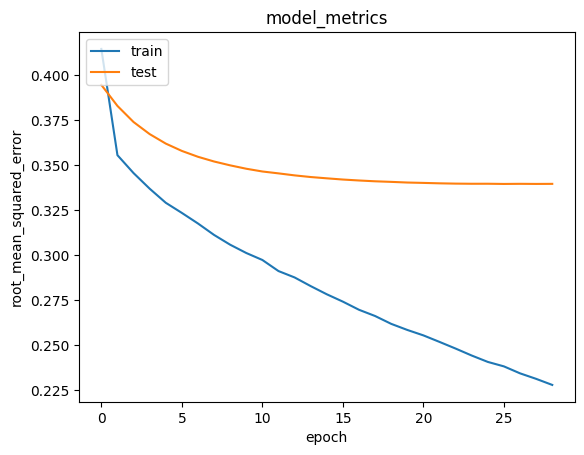

In [ ]:
plt.plot(history.history['root_mean_squared_error'])
plt.plot(history.history['val_root_mean_squared_error'])
plt.title('model_metrics')
plt.ylabel('root_mean_squared_error')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
user_id = df['User-ID'].sample(1).iloc[0]
book_visited_by_user = df[df['User-ID'] == user_id]

book_not_visited = books[~books['ISBN'].isin(book_visited_by_user.ISBN.values)]['ISBN']
book_not_visited = list(
    set(book_not_visited)
    .intersection(set(book_to_book_encoded.keys()))
)

book_not_visited = [[book_to_book_encoded.get(x)] for x in book_not_visited]
user_encoder = user_to_user_encoded.get(user_id)
user_book_array = np.hstack(
    ([[user_encoder]] * len(book_not_visited), book_not_visited)
)

**Menampilkan Rekomendasi Buku untuk Pengguna**

Pada cell ini, menampilkan hasil rekomendasi dari model yang telah dilatih untuk memprediksi rating untuk setiap buku yang belum dikunjungi oleh pengguna yang dipilih.

**Buku Berdasarkan Rating Pengguna** : Buku yang sudah pernah dinilai oleh pengguna ditampilkan terlebih dahulu, diurutkan berdasarkan rating yang tertinggi. Ini memberikan gambaran mengenai preferensi pengguna terhadap buku.

**Rekomendasi Buku Baru Berdasarkan Prediksi** : 10 buku baru yang belum dinilai oleh pengguna tetapi diprediksi akan disukai berdasarkan pola preferensi pengguna sebelumnya ditampilkan sebagai rekomendasi.

In [ ]:
ratings = model.predict(user_book_array).flatten()

top_ratings_indices = ratings.argsort()[-10:][::-1]
recommended_book_ids = [
    book_encoded_to_book.get(book_not_visited[x][0]) for x in top_ratings_indices
]

print('Showing recommendations for users: {}'.format(user_id))
print('===' * 9)
print('Book with high ratings from user')
print('----' * 8)

top_book_user = (
    book_visited_by_user.sort_values(
        by = 'Book-Rating',
        ascending=False
    )
    .head(5)
    .ISBN.values
)

book_df_rows = books[books['ISBN'].isin(top_book_user)]

for index, row in book_df_rows.iterrows():
  print(row['Book-Title'], ':', row['Book-Author'], '-', row['Publisher'])

print('----' * 8)
print('Top 10 Books recommendation')
print('----' * 8)

recommended_book = books[books['ISBN'].isin(recommended_book_ids)]
for index, row in recommended_book.iterrows():
  print(row['Book-Title'], ':', row['Book-Author'], '-', row['Publisher'])

614/614 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Showing recommendations for users: 2276
Book with high ratings from user
--------------------------------
Sudden Death : Rita Mae Brown - Bantam Doubleday Dell
Rumors and Whispers : Marilyn Levy - Fawcett Books
Out in All Directions: Almanac of Gay and Lesbian America : Lynn Witt - Warner Books
Martina: The Lives and Times of Martina Navratilova : Adrianne Blue - Carol Publishing Corporation
At Wits End : Erma Bombeck - Ballantine Books
--------------------------------
Top 10 Books recommendation
--------------------------------
Powder and Patch : Georgette Heyer - Harlequin
Knights of the Whip: Stagecoach Days in Oregon : Gary Meier - Gary &amp; Gloria Meier
GULLIVERS FUGITIVES STAR TREK NEXT GENERATION #11 (Star Trek : the Next Generation, No 11) : Keith Sharee - Star Trek
The Blood of Roses : Marsha Canham - Dell Publishing Company
Almost a Princess : ELIZABETH THORNTON - Bantam
Dazzled : Catherine Hart - Avon Books
Ugly American : Eugene Bur

Hasil yang ditampilkan mencakup:
- Buku yang sudah pernah dinilai oleh pengguna dengan rating tertinggi.
- Buku-buku baru yang direkomendasikan berdasarkan prediksi rating.